In [1]:
import os
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from linearmodels.panel import PanelOLS

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant

from scipy import stats
from scipy.stats import pearsonr, spearmanr, f_oneway
from scipy.stats.mstats import winsorize

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [2]:
# !pip install --upgrade pip
# !pip install linearmodels
# !pip install xlsxwriter

In [3]:
np.random.seed(42)

In [4]:
project_root = '/home/jovyan/project_10x'

sys.path.append(os.path.join(project_root, 'src'))

from utils import *

## Data

In [5]:
sent_df = pd.read_parquet('sent_growth_fin_risk_10k_10q.parquet')

In [6]:
sent_df = sent_df[(sent_df['industry_code'] != 'Money') & (sent_df['industry_code'] != 'Utils')].copy().reset_index(drop=True)

In [7]:
sentiment_cols = [
    'positive_financial_risk', 'negative_financial_risk', 'polarity_financial_risk', 
]

growth_cols = [
    'positive_growth_llama', 'negative_growth_llama', 'polarity_growth_llama',
]

In [8]:
sent_df[sentiment_cols].corr()

,positive_financial_risk,negative_financial_risk,polarity_financial_risk
positive_financial_risk,1.000000,-0.801616,0.948232
negative_financial_risk,-0.801616,1.000000,-0.949979
polarity_financial_risk,0.948232,-0.949979,1.000000


In [9]:
sent_df['year_month'] = sent_df['FILING_DATE'].astype(str).str[:6]

In [10]:
ts_df = sent_df.groupby('year_month').agg(
    {
     'negative_financial_risk': 'mean',
     'positive_financial_risk': 'mean',
     'polarity_financial_risk': 'mean',
     'negative_growth_llama': 'mean',
     'positive_growth_llama': 'mean',
     'polarity_growth_llama': 'mean',
    }
)

ts_df = ts_df.reset_index()
ts_df

,year_month,negative_financial_risk,positive_financial_risk,polarity_financial_risk,negative_growth_llama,positive_growth_llama,polarity_growth_llama
0,200301,0.111060,0.248359,0.137299,0.156156,0.332257,0.176101
1,200302,0.111665,0.235943,0.124278,0.151144,0.338431,0.187286
2,200303,0.127806,0.227586,0.099781,0.175105,0.328980,0.153875
3,200304,0.118748,0.241338,0.122590,0.156367,0.338215,0.181847
4,200305,0.110969,0.237872,0.126903,0.144045,0.340987,0.196942
...,...,...,...,...,...,...,...
247,202308,0.147798,0.256271,0.108473,0.114758,0.336543,0.221785
248,202309,0.140184,0.277353,0.137169,0.165820,0.349866,0.184046
249,202310,0.139635,0.267778,0.128143,0.125601,0.338559,0.212958
250,202311,0.148284,0.266649,0.118365,0.118289,0.340001,0.221712


In [11]:
ts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year_month               252 non-null    object 
 1   negative_financial_risk  252 non-null    float64
 2   positive_financial_risk  252 non-null    float64
 3   polarity_financial_risk  252 non-null    float64
 4   negative_growth_llama    252 non-null    float64
 5   positive_growth_llama    252 non-null    float64
 6   polarity_growth_llama    252 non-null    float64
dtypes: float64(6), object(1)
memory usage: 13.9+ KB


In [12]:
jlmz_sent = pd.read_excel('JLMZ_MS_Index2017.xlsx')

jlmz_sent['year_month'] = jlmz_sent['date'].str.replace('-', '')
jlmz_sent.drop('date', axis=1, inplace=True)
jlmz_sent = jlmz_sent.rename(columns={'Manager Sentiment Index': 'msi'})

df = jlmz_sent.merge(ts_df, on='year_month', how='right')

In [13]:
df[['msi', 'polarity_financial_risk', 'polarity_growth_llama']].corr()

,msi,polarity_financial_risk,polarity_growth_llama
msi,1.000000,-0.074459,0.335431
polarity_financial_risk,-0.074459,1.000000,0.439034
polarity_growth_llama,0.335431,0.439034,1.000000


In [14]:
df['polarity_financial_risk'] = (-1) * df['polarity_financial_risk']

In [15]:
df['year_month'] = pd.to_datetime(df['year_month'], format='%Y%m')

df = df.sort_values('year_month')

window_size = 4

df['msi_ma_4m'] = df['msi'].rolling(window=window_size, center=False).mean()
df['polarity_financial_risk_ma_4m'] = df['polarity_financial_risk'].rolling(window=window_size, center=False).mean()
df['polarity_growth_llama_ma_4m'] = df['polarity_growth_llama'].rolling(window=window_size, center=False).mean()

In [16]:
df.tail()

,msi,year_month,negative_financial_risk,positive_financial_risk,polarity_financial_risk,negative_growth_llama,positive_growth_llama,polarity_growth_llama,msi_ma_4m,polarity_financial_risk_ma_4m,polarity_growth_llama_ma_4m
247,NaN,2023-08-01,0.147798,0.256271,-0.108473,0.114758,0.336543,0.221785,NaN,-0.110641,0.206641
248,NaN,2023-09-01,0.140184,0.277353,-0.137169,0.165820,0.349866,0.184046,NaN,-0.118299,0.198673
249,NaN,2023-10-01,0.139635,0.267778,-0.128143,0.125601,0.338559,0.212958,NaN,-0.124753,0.205642
250,NaN,2023-11-01,0.148284,0.266649,-0.118365,0.118289,0.340001,0.221712,NaN,-0.123038,0.210125
251,NaN,2023-12-01,0.138477,0.288464,-0.149987,0.134527,0.352427,0.217900,NaN,-0.133416,0.209154


In [17]:
scaler = StandardScaler()
data_to_normalize = df[['msi_ma_4m', 'polarity_financial_risk_ma_4m', 'polarity_growth_llama_ma_4m']].dropna()
normalized_data = scaler.fit_transform(data_to_normalize)
normalized_data

normalized_df = pd.DataFrame(normalized_data, 
                            columns=['msi_ma_4m_norm', 'polarity_financial_risk_ma_4m_norm', 'polarity_growth_llama_ma_4m_norm'],
                            index=data_to_normalize.index)

dates_for_normalized = df.loc[normalized_df.index, 'year_month']
normalized_df['year_month'] = dates_for_normalized
normalized_df = normalized_df.reset_index(drop=True)

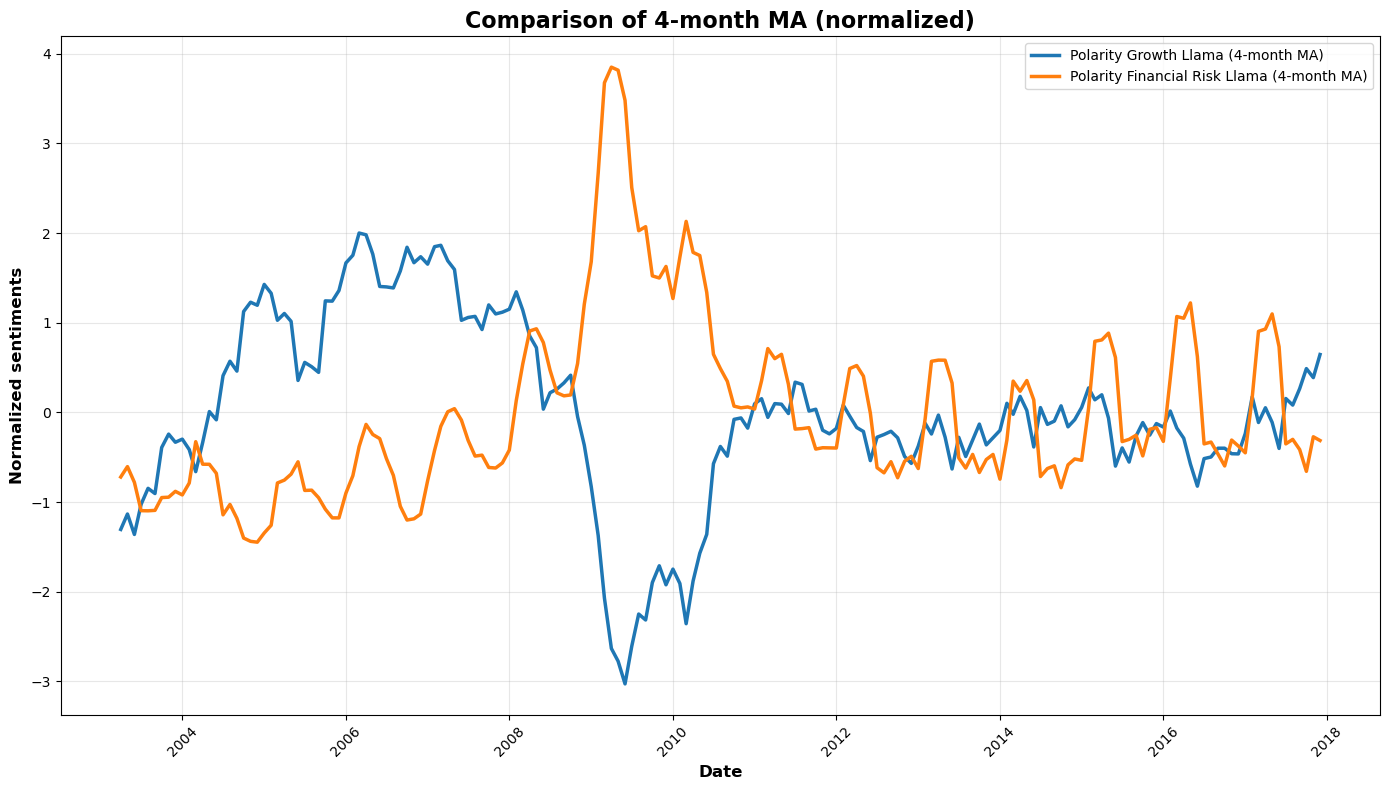

In [18]:
fig = plot_time_series(df=normalized_df, dates=dates_for_normalized,
                       cols_to_plot=['polarity_growth_llama_ma_4m_norm', 'polarity_financial_risk_ma_4m_norm'],
                       cols_labels_dict={
                         'polarity_growth_llama_ma_4m_norm': 'Polarity Growth Llama (4-month MA)',
                         'polarity_financial_risk_ma_4m_norm': 'Polarity Financial Risk Llama (4-month MA)'
                        },
                       title='Comparison of 4-month MA (normalized)'
                      )

## Model

Rmt+1 (the monthly return on the S&P 500 index in excess of the risk-free rate

In [19]:
predictor_data = pd.read_excel('PredictorData2024.xlsx')

In [20]:
predictor_data.tail()

,yyyymm,Index,D12,E12,b/m,tbl,AAA,BAA,lty,ntis,Rfree,infl,ltr,corpr,svar,csp,CRSP_SPvw,CRSP_SPvwx
1843,202408,5648.40,72.925466,198.823333,0.187377,0.0505,0.0487,0.0560,0.0387,-0.011028,0.0048,0.000814,0.012792,0.015726,0.003184,NaN,0.024283,0.022898
1844,202409,5762.48,73.400300,200.270000,0.183981,0.0472,0.0468,0.0542,0.0372,-0.010283,0.0040,0.001604,0.012023,0.017730,0.001466,NaN,0.022821,0.021707
1845,202410,5705.45,73.877618,203.570000,0.186478,0.0451,0.0495,0.0563,0.0410,-0.009458,0.0039,0.001151,-0.023811,-0.024271,0.001062,NaN,-0.008690,-0.009523
1846,202411,6032.38,74.354936,206.870000,0.173410,0.0442,0.0514,0.0578,0.0436,-0.004121,0.0040,-0.000542,0.007772,0.013377,0.001264,NaN,0.060420,0.059016
1847,202412,5881.63,74.832255,210.170000,0.183056,0.0427,0.0520,0.0580,0.0439,-0.004614,0.0037,0.000355,-0.015408,-0.019354,0.001643,NaN,-0.023445,-0.024621


In [21]:
data = predictor_data[predictor_data['yyyymm'] > 200211].copy().reset_index(drop=True)
data['year_month'] = pd.to_datetime(data['yyyymm'], format='%Y%m')

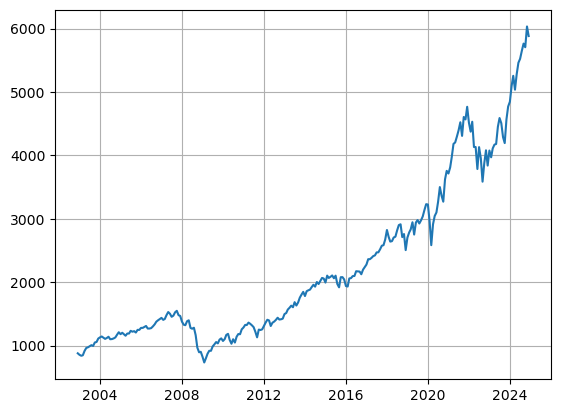

In [22]:
plt.plot(data['year_month'], data['Index'])
plt.grid()

In [23]:
data = data.sort_values('year_month')

In [24]:
data['index_return'] = data['Index'].pct_change()
data['target'] = data['index_return'] - data['Rfree']

data = data.merge(normalized_df, on='year_month', how='left')

In [25]:
data

,yyyymm,Index,D12,E12,b/m,tbl,AAA,BAA,lty,ntis,Rfree,infl,ltr,corpr,svar,csp,CRSP_SPvw,CRSP_SPvwx,year_month,index_return,target,msi_ma_4m_norm,polarity_financial_risk_ma_4m_norm,polarity_growth_llama_ma_4m_norm
0,200212,879.82,16.074000,27.590000,0.295386,0.0119,0.0621,0.0745,0.0484,0.025736,0.0011,-0.002206,0.050700,0.036100,0.002640,-0.004144,-0.058834,-0.060464,2002-12-01,NaN,NaN,NaN,NaN,NaN
1,200301,855.70,16.124000,28.500000,0.305942,0.0117,0.0617,0.0735,0.0495,0.028289,0.0010,0.004422,-0.010600,0.002100,0.005168,NaN,-0.026579,-0.027860,2003-01-01,-0.027415,-0.028415,NaN,NaN,NaN
2,200302,841.15,16.174000,29.410000,0.312251,0.0117,0.0595,0.0706,0.0472,0.027919,0.0009,0.007705,0.032900,0.026400,0.002564,NaN,-0.015246,-0.017225,2003-02-01,-0.017004,-0.017904,NaN,NaN,NaN
3,200303,848.18,16.224000,30.320000,0.286118,0.0113,0.0589,0.0695,0.0486,0.024099,0.0010,0.006008,-0.013500,-0.008000,0.006136,NaN,0.010308,0.008967,2003-03-01,0.008358,0.007358,NaN,NaN,NaN
4,200304,916.92,16.204333,31.730000,0.269654,0.0113,0.0574,0.0685,0.0481,0.019967,0.0010,-0.002172,0.010200,0.022900,0.003065,NaN,0.082774,0.081462,2003-04-01,0.081044,0.080044,-3.584048,-0.719761,-1.304779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,202408,5648.40,72.925466,198.823333,0.187377,0.0505,0.0487,0.0560,0.0387,-0.011028,0.0048,0.000814,0.012792,0.015726,0.003184,NaN,0.024283,0.022898,2024-08-01,0.022835,0.018035,NaN,NaN,NaN
261,202409,5762.48,73.400300,200.270000,0.183981,0.0472,0.0468,0.0542,0.0372,-0.010283,0.0040,0.001604,0.012023,0.017730,0.001466,NaN,0.022821,0.021707,2024-09-01,0.020197,0.016197,NaN,NaN,NaN
262,202410,5705.45,73.877618,203.570000,0.186478,0.0451,0.0495,0.0563,0.0410,-0.009458,0.0039,0.001151,-0.023811,-0.024271,0.001062,NaN,-0.008690,-0.009523,2024-10-01,-0.009897,-0.013797,NaN,NaN,NaN
263,202411,6032.38,74.354936,206.870000,0.173410,0.0442,0.0514,0.0578,0.0436,-0.004121,0.0040,-0.000542,0.007772,0.013377,0.001264,NaN,0.060420,0.059016,2024-11-01,0.057301,0.053301,NaN,NaN,NaN


### Control variables

we use 14 monthly economic variables that are linked directly to macroeconomic fundamentals, which are 
- the log dividend-price ratio (DP): log of a 12-month moving sum of dividends paid on the S&P 500 index minus the log of stock prices (S&P 500 index) 
- log dividend yield (DY): difference between the log of dividends and the log of lagged prices
- log earnings-price ratio (EP): difference between the log of earnings on the S&P 500 index and the log of prices, where earnings is measured using a one-year moving sum 
- log dividend-payout ratio (DE): difference between the log of dividends and the log of earnings on the S&P 500 index
- stock return variance (SVAR),
- book-to-market ratio (BM),
- net equity expansion (NTIS),
- Treasury bill rate (TBL), 
- long-term bond yield (LTY),
- long-term bond return (LTR), 
- term spread (TMS): difference between the long-term yield and the Treasury bill rate
- default yield spread (DFY): difference between BAA- and AAA-rated corporate bond yields
- default return spread (DFR): difference between the long-term corporate bond return and the long-term government bond return.
- inflation rate (INFL).

In [26]:
data['log_DP'] = np.log(data['D12']) - np.log(data['Index'])

data['lag_Index'] = data['Index'].shift(1)
data['log_DY'] = np.log(data['D12']) - np.log(data['lag_Index'])

data['log_EP'] = np.log(data['E12']) - np.log(data['Index'])
data['log_DE'] = np.log(data['D12']) - np.log(data['E12'])
data['tms'] = data['lty'] - data['tbl']
data['dfy'] = data['BAA'] - data['AAA']
data['dfr'] = data['corpr'] - data['ltr']

In [27]:
data = data.rename(columns={'b/m': 'bm'})

In [28]:
# control_variables = ['log_DP', 'log_DY', 'log_EP', 'log_DE', 'svar', 'b/m', 'ntis', 'tbl', 'lty', 'ltr', 'tms', 'dfy', 'dfr', 'infl']
control_variables = ['log_DP', 'log_EP', 'svar', 'bm', 'ntis', 'tbl', 'lty', 'ltr', 'tms', 'dfy', 'dfr', 'infl']
len(control_variables)

12

In [30]:
data[control_variables].describe()

,log_DP,log_EP,svar,bm,ntis,tbl,lty,ltr,tms,dfy,dfr,infl
count,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000
mean,-3.989553,-3.122190,0.002939,0.284885,-0.006511,0.015557,0.034194,0.004385,0.018636,0.010253,0.000647,0.002102
std,0.172141,0.353958,0.006649,0.059840,0.016852,0.017921,0.012188,0.030807,0.015737,0.004121,0.019313,0.003945
min,-4.396047,-4.836478,0.000150,0.173410,-0.055954,0.000100,0.006200,-0.112400,-0.015700,0.005500,-0.097600,-0.019153
25%,-4.074094,-3.201425,0.000746,0.238168,-0.017425,0.000900,0.025800,-0.015330,0.005800,0.007900,-0.006600,-0.000354
50%,-3.973667,-3.086025,0.001363,0.286118,-0.008504,0.009000,0.034900,0.002438,0.019200,0.009300,0.000700,0.002017
75%,-3.899373,-2.911181,0.002705,0.330671,0.007936,0.023900,0.044900,0.023000,0.032300,0.011300,0.008000,0.004741
max,-3.281006,-2.565551,0.073153,0.446141,0.028289,0.053400,0.054200,0.144300,0.045300,0.033800,0.073700,0.013736


In [31]:
data[control_variables].corr()

,log_DP,log_EP,svar,bm,ntis,tbl,lty,ltr,tms,dfy,dfr,infl
log_DP,1.000000,-0.270335,0.389299,0.755450,-0.401352,-0.420511,-0.045138,0.117388,0.443922,0.724724,-0.039346,-0.287781
log_EP,-0.270335,1.000000,-0.184919,0.049014,0.249237,0.108182,0.068357,0.070199,-0.070259,-0.527193,-0.219181,-0.000252
svar,0.389299,-0.184919,1.000000,0.156341,-0.238764,-0.129036,-0.062083,0.205030,0.098866,0.512920,-0.366515,-0.284670
bm,0.755450,0.049014,0.156341,1.000000,0.109420,-0.470258,0.118737,0.107927,0.627488,0.426404,-0.008101,-0.200219
ntis,-0.401352,0.249237,-0.238764,0.109420,1.000000,-0.231569,0.103314,0.017893,0.343724,-0.451915,0.039535,0.117523
tbl,-0.420511,0.108182,-0.129036,-0.470258,-0.231569,1.000000,0.508336,-0.005418,-0.745119,-0.188836,-0.037914,0.064805
lty,-0.045138,0.068357,-0.062083,0.118737,0.103314,0.508336,1.000000,-0.049977,0.195563,0.042768,-0.019754,0.022932
ltr,0.117388,0.070199,0.205030,0.107927,0.017893,-0.005418,-0.049977,1.000000,-0.032535,0.069529,-0.396099,-0.265620
tms,0.443922,-0.070259,0.098866,0.627488,0.343724,-0.745119,0.195563,-0.032535,1.000000,0.248170,0.027878,-0.056040
dfy,0.724724,-0.527193,0.512920,0.426404,-0.451915,-0.188836,0.042768,0.069529,0.248170,1.000000,0.093000,-0.267343


## Table 2

In [32]:
target = 'target'

In [33]:
data[f'index_return'] = data['Index'].pct_change(periods=1)
data['index_return'] = (data['index_return'] - data['Rfree'])

data['cum_return'] = (1 + data['index_return']).cumprod()
data['net_cum_return'] = data['cum_return'] - 1

In [34]:
return_names = []

for period in [1, 3, 6, 9, 12, 24, 36]:
    return_names.append(f'net_cum_return{period}')

In [35]:
for i in data.index:
    
    working_data = data.loc[i:i+37].copy()
    working_data['net_cum_return'] = (1 + working_data['index_return']).cumprod() - 1

    for period in [1, 3, 6, 9, 12, 24, 36]:

        working_data[f'net_cum_return{period}'] = working_data['net_cum_return'].shift(periods=-period)
    
    data.loc[i, return_names] = working_data[return_names].iloc[0]

In [36]:
# data[return_names] = data[return_names] * 100

In [37]:
data = data.merge(df, on='year_month', how='left')

In [38]:
for sentiment in ['msi', 
                  'negative_growth_llama', 'positive_growth_llama', 'polarity_growth_llama',
                  'negative_financial_risk', 'positive_financial_risk', 'polarity_financial_risk']:

    ss = StandardScaler()
    data[f"{sentiment}_norm"] = ss.fit_transform(data[[sentiment]])

In [39]:
[col for col in data.columns if 'msi' in col]

['msi_ma_4m_norm', 'msi', 'msi_ma_4m', 'msi_norm']

In [40]:
[col for col in data.columns if 'financial' in col]

['polarity_financial_risk_ma_4m_norm',
 'negative_financial_risk',
 'positive_financial_risk',
 'polarity_financial_risk',
 'polarity_financial_risk_ma_4m',
 'negative_financial_risk_norm',
 'positive_financial_risk_norm',
 'polarity_financial_risk_norm']

In [41]:
# Jiang period
data_ = data[data['yyyymm'].between(200301, 201412)].copy().reset_index(drop=True)

In [47]:
features_res, table_res = fit_one_factor(data_, 'msi_norm', return_names)
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.018**,-2.403,9.079,0.016
net_cum_return3,-0.035***,-2.689,15.392,0.007
net_cum_return6,-0.049***,-2.577,15.59,0.01
net_cum_return9,-0.063***,-2.815,17.681,0.005
net_cum_return12,-0.065***,-2.567,14.847,0.01
net_cum_return24,-0.074*,-1.949,8.831,0.051
net_cum_return36,-0.081**,-2.037,6.883,0.042


In [48]:
features_res, table_res = fit_one_factor(data_, 'polarity_financial_risk_ma_4m_norm', return_names)
table_res

,coef,t,r2_adj,pval
net_cum_return1,0.004,0.553,-0.205,0.58
net_cum_return3,0.009,0.621,0.368,0.535
net_cum_return6,0.018,0.898,1.62,0.369
net_cum_return9,0.029,1.383,3.401,0.167
net_cum_return12,0.039**,2.147,5.449,0.032
net_cum_return24,0.087***,3.17,13.128,0.002
net_cum_return36,0.131***,4.338,20.226,0.0


In [44]:
features_res, table_res = fit_one_factor(data, 'polarity_financial_risk_ma_4m_norm', return_names)
table_res

,coef,t,r2_adj,pval
net_cum_return1,0.004,0.596,-0.085,0.551
net_cum_return3,0.008,0.568,0.254,0.57
net_cum_return6,0.016,0.862,1.381,0.389
net_cum_return9,0.027,1.398,3.084,0.162
net_cum_return12,0.037**,2.175,4.903,0.03
net_cum_return24,0.082***,3.141,12.048,0.002
net_cum_return36,0.119***,3.903,17.448,0.0


In [45]:
features_res, table_res = fit_one_factor(data, 'polarity_financial_risk_ma_4m_norm', return_names, control_variables)
table_res

,coef,t,r2_adj,pval
net_cum_return1,0.002,0.226,32.017,0.821
net_cum_return3,-0.017,-1.63,41.522,0.103
net_cum_return6,-0.033***,-2.73,52.911,0.006
net_cum_return9,-0.028**,-2.12,55.847,0.034
net_cum_return12,-0.022,-1.434,53.986,0.152
net_cum_return24,-0.057***,-2.623,76.666,0.009
net_cum_return36,-0.003,-0.186,85.603,0.852


In [49]:
features_res, table_res = fit_one_factor(data, 'polarity_growth_llama_ma_4m_norm', return_names)
table_res

,coef,t,r2_adj,pval
net_cum_return1,-0.013**,-2.282,4.204,0.022
net_cum_return3,-0.026**,-2.387,8.807,0.017
net_cum_return6,-0.046***,-2.681,15.057,0.007
net_cum_return9,-0.066***,-2.848,22.001,0.004
net_cum_return12,-0.083***,-2.904,27.279,0.004
net_cum_return24,-0.154***,-3.564,43.858,0.0
net_cum_return36,-0.208***,-4.608,54.116,0.0


In [50]:
res_ = ols_new_west(data, x_vars=['polarity_growth_llama_norm', 'polarity_financial_risk_norm'],
                    target='net_cum_return36')
print(res_.summary())

                            OLS Regression Results                            
Dep. Variable:       net_cum_return36   R-squared:                       0.268
Model:                            OLS   Adj. R-squared:                  0.262
Method:                 Least Squares   F-statistic:                     9.412
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           0.000119
Time:                        21:22:44   Log-Likelihood:                 14.356
No. Observations:                 228   AIC:                            -22.71
Df Residuals:                     225   BIC:                            -12.42
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [55]:
res_ = ols_new_west(data, x_vars=['polarity_growth_llama_norm', 'positive_financial_risk_norm'],
                    target='net_cum_return36')
print(res_.summary())

                            OLS Regression Results                            
Dep. Variable:       net_cum_return36   R-squared:                       0.270
Model:                            OLS   Adj. R-squared:                  0.263
Method:                 Least Squares   F-statistic:                     11.74
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.41e-05
Time:                        21:23:15   Log-Likelihood:                 14.625
No. Observations:                 228   AIC:                            -23.25
Df Residuals:                     225   BIC:                            -12.96
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [56]:
res_ = ols_new_west(data, x_vars=['polarity_growth_llama_norm', 'negative_financial_risk_norm'],
                    target='net_cum_return36')
print(res_.summary())

                            OLS Regression Results                            
Dep. Variable:       net_cum_return36   R-squared:                       0.265
Model:                            OLS   Adj. R-squared:                  0.259
Method:                 Least Squares   F-statistic:                     6.849
Date:                Mon, 27 Apr 2026   Prob (F-statistic):            0.00130
Time:                        21:23:18   Log-Likelihood:                 13.899
No. Observations:                 228   AIC:                            -21.80
Df Residuals:                     225   BIC:                            -11.51
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

## VIX

In [57]:
vix = pd.read_csv('VIX_History.csv')

In [58]:
vix['DATE'] = pd.to_datetime(vix['DATE'])
vix['year_month'] = vix['DATE'].astype(str).str[:7]

In [59]:
ss = StandardScaler()
vix['close_norm'] = ss.fit_transform(vix[['CLOSE']])

In [60]:
vix_df = vix.groupby('year_month').agg(
    {'close_norm': 'mean',}
)
vix_df.columns = ['vix_norm']

vix_df = vix_df.reset_index()
vix_df['year_month'] = pd.to_datetime(vix_df['year_month'])

In [95]:
data_v = data.merge(vix_df, on='year_month', how='left')

In [96]:
data_v['sent_vix'] = data_v['polarity_financial_risk_norm'] * data_v['vix_norm']

In [97]:
# data['polarity_financial_risk_norm'] = (-1) * data['polarity_financial_risk_norm']

In [98]:
mask = ~data_v['polarity_financial_risk_ma_4m_norm'].isnull()

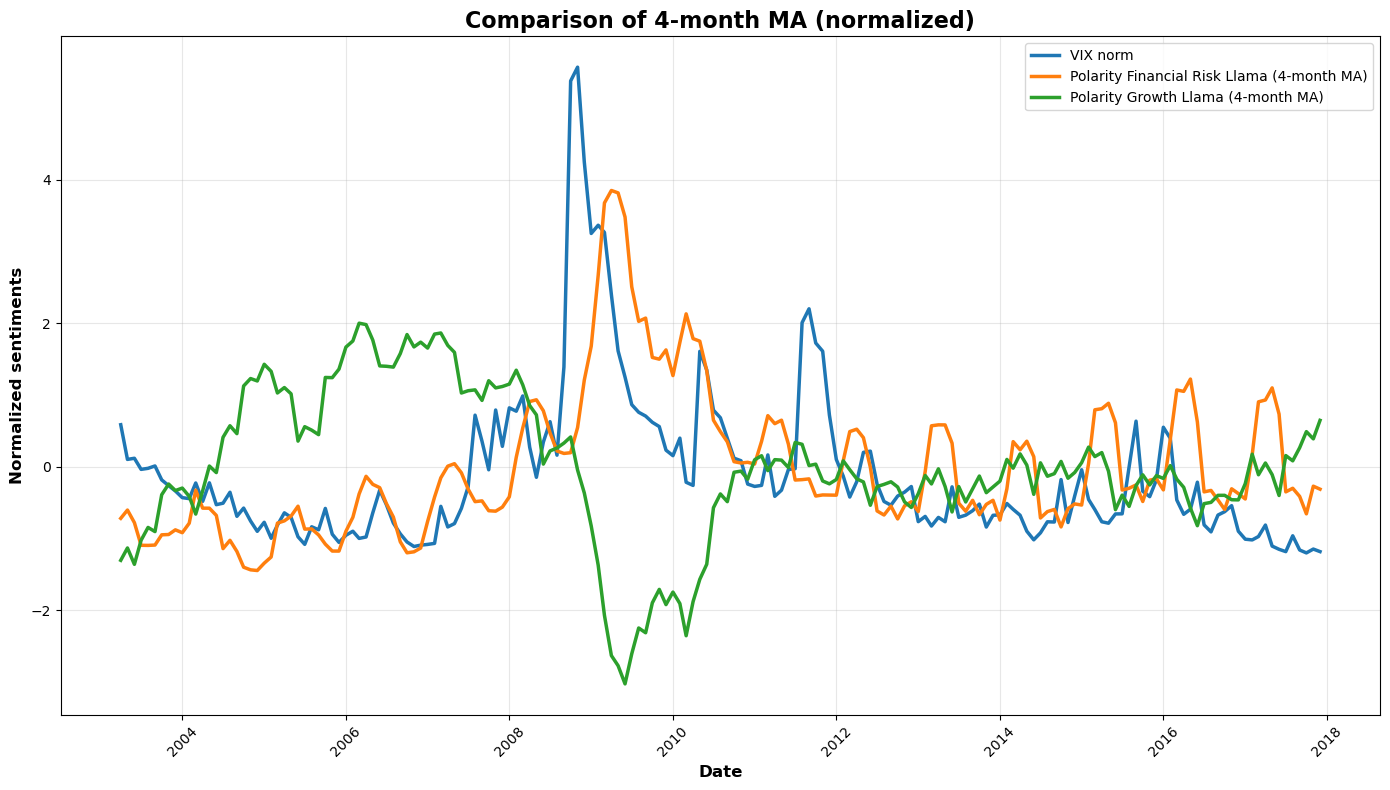

In [99]:
fig = plot_time_series(df=data_v[mask], dates=data_v[mask]['year_month'],
                       cols_to_plot=['vix_norm', 'polarity_financial_risk_ma_4m_norm', 'polarity_growth_llama_ma_4m_norm'],
                       cols_labels_dict={
                         'vix_norm': 'VIX norm',
                         'polarity_financial_risk_ma_4m_norm': 'Polarity Financial Risk Llama (4-month MA)',
                         'polarity_growth_llama_ma_4m_norm': 'Polarity Growth Llama (4-month MA)'
                        },
                       title='Comparison of 4-month MA (normalized)'
                      )

In [100]:
data_v['sent_vix'] = data_v['polarity_growth_llama_norm'] * data_v['vix_norm']

In [101]:
data_v['growth_fin_risk'] = data_v['polarity_growth_llama_norm'] * data_v['polarity_financial_risk_ma_4m_norm']

In [102]:
res_v = ols_new_west(data_v, x_vars=['polarity_growth_llama_norm', 'polarity_financial_risk_ma_4m_norm', 'growth_fin_risk'], 
                     target='net_cum_return12')
print(res_v.summary())

                            OLS Regression Results                            
Dep. Variable:       net_cum_return12   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     9.243
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.05e-05
Time:                        21:30:14   Log-Likelihood:                 105.35
No. Observations:                 177   AIC:                            -202.7
Df Residuals:                     173   BIC:                            -190.0
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

In [103]:
mask = ~data_v['polarity_financial_risk_ma_4m_norm'].isnull()

In [92]:
# res_v = ols_new_west(data_v, x_vars=['polarity_growth_llama_norm', 'vix_norm', 'sent_vix'], target='net_cum_return12')
# print(res_v.summary())

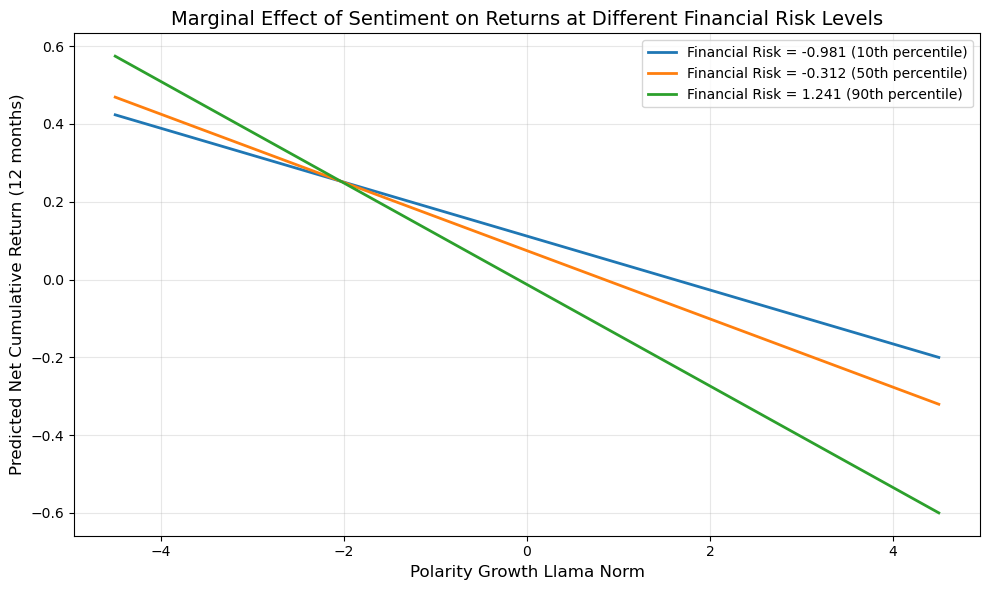

In [107]:
plot_prediction_for_different_risks(df=data_v[mask], 
                                    model_results=res_v,
                                    x_vars=['polarity_growth_llama_norm', 'polarity_financial_risk_ma_4m_norm', 'growth_fin_risk'],
                                    risk_col='polarity_financial_risk_ma_4m_norm',
                                    polarity_values=np.linspace(-4.5, 4.5, 100),
                                    risk_name='Financial Risk',
                                    xlabel='Polarity Growth Llama Norm',
                                    ylabel='Predicted Net Cumulative Return (12 months)'
                                   )